# Project KTB1: dLCA of Lovastatin Production

**Author**: ADA ROBINSON
**Date**: 2025-01-05  
**Environment**: `pharma`
**Software & Library Versions**
- Brightway25 version 1.0.6  
- bw2io version 0.9.4  
- Numpy version 1.24.4  
- Python version 3.11.11
  
**Data Sources**:  
- Ecoinvent v3.10 (cut-off system)  
- KTB1 model (DTU)

---

## Project Overview
> **What**: This notebook focuses on **electricity demand** KTB1 model for lovastatin production, and sets up a Brightway2.5 environment to perform a first dynamic LCA calculation for a whole day.

> **How**:

1. We import the necessary libraries (Brightway2.5, bw2io, etc.) and data sources (Ecoinvent 3.10).
2. We read and prepare two CSV files:
3. A file with hourly electricity demand for the KTB1 process (e.g. the CSTR, Hydrocyclone, Centrifuge, and Pump data).
4. A file with hourly electricity production shares for DK (e.g. fraction of coal, wind, biomass, etc.).
5. We map each electricity generation technology to the relevant Brightway activity in the custom database.
6. We build a functional unit (FU) matrix for each hour by multiplying the KTB1 electricity consumption by the respective technology shares.
7. We then perform an LCA calculation using the ReCiPe 2016 v1.03 endpoint (E), total: ecosystem quality method to obtain the impact score at each point

> **Why (Intended Outcome)**: We aim to quantify and compare the environmental impacts of the hourly electricity consumption in lovastatin production using bw_temporalis, capturing time-varying emissions and impacts.


## Libraries Import

In [1]:
#Brightway imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bw2io as bi
import bw2calc as bc
import bw2data as bd
import bw2analyzer as ba
import os
import brightway2 as bw

10:40:32 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


In [2]:
#Temporalis imports
import bw_graph_tools as graph
from bw_temporalis import (
    easy_timedelta_distribution, 
    easy_datetime_distribution, 
    TemporalisLCA, 
    Timeline, 
    TemporalDistribution
)
from bw_temporalis.lcia import characterize_methane, characterize_co2

### Set Project & Import ecoinvent

In [3]:
#list(bw.projects)

In [4]:
bw.projects.set_current("[BW25] pharma")
print("Current project:", bw.projects.current)

Current project: [BW25] pharma


In [5]:
#bd.projects.set_current("[BW25] pharma")
#print("Is ''[BW25] pharma'' in 2.5 format?", bd.projects.twofive)

In [6]:
bd.databases

Databases dictionary with 5 object(s):
	Electricity KTB1
	KTB1_dynamic
	biosphere3
	ecoinvent-3.10-cutoff
	electricity_ktb1

In [7]:
#bi.import_ecoinvent_release('3.10', 'cutoff', 'adarobinsonmedici', 'Ecoinvent37725921!')

### Load KTB1 Electricity Demand

In [8]:
DATA_DIR = r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories"
infile = os.path.join(DATA_DIR, "lci_pharma_dynamic.csv") #infile will always have the same name
df = pd.read_csv(infile, usecols=[0,1,2,3,4])

# Rename columns
df.columns = [col.lower() for col in df.columns]
df = df.rename(columns={
    "time": "Time",
    "data_1": "CSTR",
    "data_2": "Hydrocyclone",
    "data_3": "Centrifuge",
    "data_4": "Pump",
})

# Compute 'Total'
df["Total"] = df["CSTR"] + df["Hydrocyclone"] + df["Centrifuge"] + df["Pump"]
df = df.iloc[:24]  # Only first 24 hours
df

,Time,CSTR,Hydrocyclone,Centrifuge,Pump,Total
0,0,22.19214,2.19562,13.62883,5.86381,43.88040
1,1,22.19214,1.16313,13.62883,5.86381,42.84791
2,2,19.80610,1.16313,13.62886,5.75665,40.35474
3,3,20.00377,1.62519,13.62888,5.77763,41.03547
4,4,20.05318,2.00616,13.62891,5.78951,41.47776
5,5,20.05994,2.06662,13.62893,5.79874,41.55423
6,6,20.05995,2.06684,13.62895,5.80735,41.56309
7,7,20.05995,2.06733,13.62898,5.81569,41.57195
8,8,20.05996,2.06811,13.62900,5.82387,41.58094
9,9,20.05997,2.06897,13.62902,5.83194,41.58990


In [9]:
#print(len(df)) 
#print(len(df.columns))

Text(0.5, 1.0, 'Dynamic LCA Inventory')

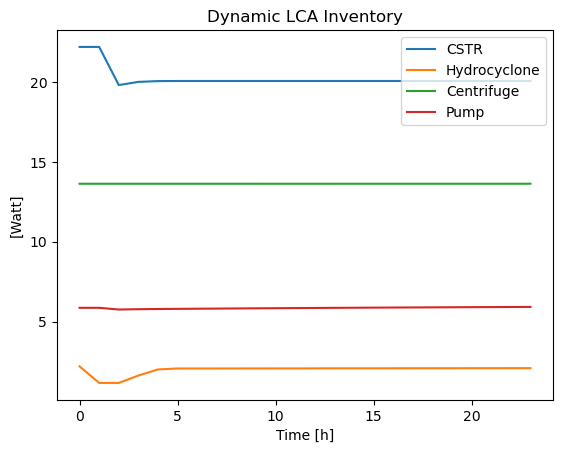

In [10]:
df.iloc[:,1:5].plot()
plt.xlabel('Time [h]')
plt.ylabel('[Watt]')
plt.title('Dynamic LCA Inventory')

In [11]:
#sns.pairplot(df.iloc[:,1:]) #The plot displays pairwise scatter plots for all numerical variables in the DataFrame.
                              #Diagonal Plots show histograms for each individual variable, representing their distributions.
                              #Off-Diagonal Plots are scatter plots showing relationships between two variables.

### Import & Create Custom Database "electricity_ktb1"

In [12]:
imp = bw.ExcelImporter(r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories\elect_db_dk_ab.xlsx")

Extracted 1 worksheets in 0.07 seconds


In [13]:
imp.apply_strategies()
imp.match_database("ecoinvent-3.10-cutoff", fields=("name","unit","location","reference product"))
imp.match_database(fields=("name","unit","location"))
print("\n-- Database stats --")
imp.statistics()

Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.22 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields

-- Database stats --
Graph statistics for `Electricity KTB1` importer:
8 graph nodes:
	process: 8
235 graph edges:
	biosphere

(8, 235, 0, 0)

In [14]:
# If there are unlinked flows, you can see them:
print("Unlinked flows:", list(imp.unlinked))

Unlinked flows: []


In [15]:
imp.write_database() # Now write the database

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 244.26it/s]


10:41:05 [info     ] Vacuuming database            
Created database: Electricity KTB1


### Databases Confirmation & Selection

In [16]:
print("\nDatabases in current project:")
print(bd.databases)


Databases in current project:
Databases dictionary with 5 object(s):
	Electricity KTB1
	KTB1_dynamic
	biosphere3
	ecoinvent-3.10-cutoff
	electricity_ktb1


In [17]:
# We want to use "electricity_ktb1" for referencing
if "electricity_ktb1" in bd.databases:
    db_ktb1_name = "electricity_ktb1"
elif "Electricity KTB1" in bd.databases:
    db_ktb1_name = "Electricity KTB1"
else:
    raise ValueError("No 'electricity_ktb1' or 'Electricity KTB1' found in databases!")

In [18]:
el_dk_1 = bw.Database(db_ktb1_name)
print(f"\nCustom DB to use => {db_ktb1_name}")
print("Number of activities:", len(el_dk_1))


Custom DB to use => electricity_ktb1
Number of activities: 8


In [22]:
el_prod_dk_1 = [a for a in el_dk_1 if 'electricity' or 'heat' in a ['name']]
el_prod_dk_1

['electricity production, wind, >3MW turbine, onshore' (kilowatt hour, DK, None),
 'electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted' (kilowatt hour, DK, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, DK, None),
 'heat and power co-generation, biogas, gas engine' (kilowatt hour, DK, None),
 'electricity production, oil' (kilowatt hour, DK, None),
 'heat and power co-generation, hard coal' (megajoule, DK, None),
 'heat and power co-generation, natural gas, conventional power plant, 100MW electrical' (megajoule, DK, None),
 'electricity production, wind, 1-3MW turbine, offshore' (kilowatt hour, DK, None)]

In [23]:
#activities_as_dicts = [act.as_dict() for act in el_prod_dk_1]
#activities_as_dicts

In [24]:
activities_info = []
for act in el_prod_dk_1:
    # You decide which keys you want to include or rename
    d = {
        'name': act['name'],
        'amount': 1,  # or some real value
        'database': act['database'],
        'location': act['location'],
        'unit': act['unit'],
        'type': act.get('type', 'unknown'),  # or "production"/"technosphere" as needed
        'reference product': act.get('reference product', None),
    }
    activities_info.append(d)

#activities_info

### Load DK Electricity Shares - from CSV

In [25]:
e_dk = pd.read_csv(r"C:\Users\arobinson\Desktop\DynamicLCA\Inventories\20250114_elect_dk.csv")
e_dk.head(1)

,Area,MTU,Biomass - Actual Aggregated [MW],Fossil Brown coal/Lignite - Actual Aggregated [MW],Fossil Coal-derived gas - Actual Aggregated [MW],Fossil Gas - Actual Aggregated [MW],Fossil Hard coal - Actual Aggregated [MW],Fossil Oil - Actual Aggregated [MW],Fossil Oil shale - Actual Aggregated [MW],Fossil Peat - Actual Aggregated [MW],...,Hydro Run-of-river and poundage - Actual Aggregated [MW],Hydro Water Reservoir - Actual Aggregated [MW],Marine - Actual Aggregated [MW],Nuclear - Actual Aggregated [MW],Other - Actual Aggregated [MW],Other renewable - Actual Aggregated [MW],Solar - Actual Aggregated [MW],Waste - Actual Aggregated [MW],Wind Offshore - Actual Aggregated [MW],Wind Onshore - Actual Aggregated [MW]
0,Denmark (DK),14.01.2025 00:00 - 14.01.2025 01:00 (CET/CEST),579,n/e,n/e,137,262,34,n/e,n/e,...,n/e,n/e,n/e,n/e,n/e,n/e,0,76,2223,3420


In [26]:
# Replace 'n/e' with 0 and convert to numeric BEFORE summing:
e_dk.iloc[:, 2:] = (
    e_dk.iloc[:, 2:]
    .replace("n/e", 0)
    .apply(pd.to_numeric, errors="coerce")
)

# Convert the time or hour into a simple integer index 
e_dk["MTU"] = range(len(e_dk)) 

# Select only numeric columns among the columns 2: onwards
cols_to_sum = e_dk.iloc[:, 2:].select_dtypes(include="number").columns 

# Now sum only these numeric columns
e_dk["Sum_elec_prod"] = e_dk[cols_to_sum].sum(axis=1)

e_dk.head(1)
#e_dk2.shape 
#e_dk2.info

C:\Users\arobinson\AppData\Local\Temp\ipykernel_37280\131688600.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("n/e", 0)


,Area,MTU,Biomass - Actual Aggregated [MW],Fossil Brown coal/Lignite - Actual Aggregated [MW],Fossil Coal-derived gas - Actual Aggregated [MW],Fossil Gas - Actual Aggregated [MW],Fossil Hard coal - Actual Aggregated [MW],Fossil Oil - Actual Aggregated [MW],Fossil Oil shale - Actual Aggregated [MW],Fossil Peat - Actual Aggregated [MW],...,Hydro Water Reservoir - Actual Aggregated [MW],Marine - Actual Aggregated [MW],Nuclear - Actual Aggregated [MW],Other - Actual Aggregated [MW],Other renewable - Actual Aggregated [MW],Solar - Actual Aggregated [MW],Waste - Actual Aggregated [MW],Wind Offshore - Actual Aggregated [MW],Wind Onshore - Actual Aggregated [MW],Sum_elec_prod
0,Denmark (DK),0,579,0,0,137,262,34,0,0,...,0,0,0,0,0,0,76,2223,3420,6731


In [27]:
e_dk2 = e_dk.dropna(axis=1)

# This will be useful when uploading an yearly database. Slice the 24-hour rows (assuming exactly 24 rows), numeric columns only
df_day1 = e_dk.iloc[0:24, 2:-1]

# Calculate sums per column
sums_day1 = df_day1.sum(axis=1)

# Replace zeros in sums with NaN, to avoid division-by-zero
sums_day1 = sums_day1.replace({0: np.nan})

# Compute percentage of each cell relative to column total
percentage1 = df_day1.div(sums_day1, axis=0).fillna(0)

# Rename and add these percentage columns into e_dk
percentage1 = percentage1.add_suffix('_pct')  # e.g. "Biomass - Actual Aggregated [MW]_pct"
e_dk[percentage1.columns] = percentage1

C:\Users\arobinson\AppData\Local\Temp\ipykernel_37280\3745175061.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sums_day1 = sums_day1.replace({0: np.nan})
C:\Users\arobinson\AppData\Local\Temp\ipykernel_37280\3745175061.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  percentage1 = df_day1.div(sums_day1, axis=0).fillna(0)


In [28]:
percentage1["Sum_elec_prod_pct"] = (
    percentage1.drop(columns="Sum_elec_prod_pct", errors="ignore").sum(axis=1)
)
percentage1.head(1)

,Biomass - Actual Aggregated [MW]_pct,Fossil Brown coal/Lignite - Actual Aggregated [MW]_pct,Fossil Coal-derived gas - Actual Aggregated [MW]_pct,Fossil Gas - Actual Aggregated [MW]_pct,Fossil Hard coal - Actual Aggregated [MW]_pct,Fossil Oil - Actual Aggregated [MW]_pct,Fossil Oil shale - Actual Aggregated [MW]_pct,Fossil Peat - Actual Aggregated [MW]_pct,Geothermal - Actual Aggregated [MW]_pct,Hydro Pumped Storage - Actual Aggregated [MW]_pct,...,Hydro Water Reservoir - Actual Aggregated [MW]_pct,Marine - Actual Aggregated [MW]_pct,Nuclear - Actual Aggregated [MW]_pct,Other - Actual Aggregated [MW]_pct,Other renewable - Actual Aggregated [MW]_pct,Solar - Actual Aggregated [MW]_pct,Waste - Actual Aggregated [MW]_pct,Wind Offshore - Actual Aggregated [MW]_pct,Wind Onshore - Actual Aggregated [MW]_pct,Sum_elec_prod_pct
0,0.08602,0.0,0.0,0.020354,0.038924,0.005051,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.011291,0.330263,0.508097,1.0


In [29]:
#print(len(percentage1)) 
#print(len(percentage1.columns))

In [30]:
#print(df_day1.dtypes)

In [31]:
# print(percentage1.head(24))

### Mapping Technologies -> ACTIVITIES

In [32]:
# We'll assume we want to reference 'electricity_ktb1' (or "Electricity KTB1") DB.
# Make sure these process names actually exist in el_dk_1
mapping = {
    "Fossil Hard coal - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "heat and power co-generation, hard coal"),
    "Fossil Oil - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "electricity production, oil"),
    "Fossil Gas - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "heat and power co-generation, natural gas, conventional power plant, 100MW electrical"),
    "Wind Offshore - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "electricity production, wind, 1-3MW turbine, offshore"),
    "Wind Onshore - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "electricity production, wind, >3MW turbine, onshore"),
    "Biomass - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "heat and power co-generation, biogas, gas engine"),
    "Waste - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "electricity, from municipal waste incineration to generic market for electricity, medium voltage"),
    "Solar - Actual Aggregated [MW]_pct":
        (db_ktb1_name, "electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted"),
}


### Recipe Method (from ecoinvent Import)

In [38]:
list(bd.methods)

[('CML v4.8 2016 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: freshwater no LT',
  'freshwater aquatic ecotoxicity (FAETP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: marine no LT',
  'marine aquatic ecotoxicity (MAETP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'ecotoxicity: terrestrial no LT',
  'terrestrial ecotoxicity (TETP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'energy resources: non-renewable no LT',
  'abiotic depletion potential (ADP): fossil fuels no LT'),
 ('CML v4.8 2016 no LT',
  'eutrophication no LT',
  'eutrophication (fate not incl.) no LT'),
 ('CML v4.8 2016 no LT',
  'human toxicity no LT',
  'human toxicity (HTP inf) no LT'),
 ('CML v4.8 2016 no LT',
  'material resources: metals/minerals no LT',
  'abiotic depletion potential (ADP): elements (ultimate reserves) no LT'),
 ('CML v4.8 2016 no LT',
  'ozone depletion no LT',
  'ozone layer depletion (ODP steady state) no LT'),
 ('CML v4

In [34]:
recipe = [m for m in bd.methods if 'ReCiPe' in str(m) and 'ecosystem' in str(m) and 'total' in str(m) and 'endpoint (E)' in str(m) and 'LT' not in str(m)] 
recipe

[('ReCiPe 2016 v1.03, endpoint (E)',
  'total: ecosystem quality',
  'ecosystem quality')]

In [39]:
method = ('ReCiPe 2016 v1.03, endpoint (E)',
  'total: ecosystem quality',
  'ecosystem quality')
print("\nChosen LCIA method:", method)


Chosen LCIA method: ('ReCiPe 2016 v1.03, endpoint (E)', 'total: ecosystem quality', 'ecosystem quality')


In [40]:
print("\nCheck that the method exists in bd.methods:")
assert method in bd.methods, f"Method {method} not found in bd.methods"
print("All good so far! You can now proceed to build a functional unit, do LCA, etc.")


Check that the method exists in bd.methods:
All good so far! You can now proceed to build a functional unit, do LCA, etc.


In [41]:
import bw2io
bw2io.create_default_lcia_methods(overwrite=True)
bd.methods.process()  # finalize the import

ValueError: Can't understand elementary flow identifier ['biosphere3', '9990b51b-7023-4700-bca0-1a32ef921f74'] in data line (['biosphere3', '9990b51b-7023-4700-bca0-1a32ef921f74'], 1.6)